In [13]:
from pathlib import Path
import pandas as pd
from dotenv import load_dotenv
import os
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
load_dotenv()

True

In [16]:
db_host = os.getenv("DB_HOST")
db_name = os.getenv("DB_NAME")
db_user = os.getenv("DB_USER")
db_password = os.getenv("DB_PASSWORD")
db_port = os.getenv("DB_PORT")

In [17]:
db_url = URL.create(
    drivername="postgresql+psycopg2",
    username=db_user,
    password=db_password,
    host=db_host,
    port=int(db_port) if db_port else 5432,
    database=db_name,
 )
engine = create_engine(db_url)

In [18]:
c_df = pd.read_sql(text("SELECT * FROM dim_company"), con=engine)
s_df = pd.read_sql(text("SELECT * FROM dim_sector"), con=engine)
y_df = pd.read_sql(text("SELECT * FROM dim_year"), con=engine)
bs_df = pd.read_sql(text("SELECT * FROM fact_balance_sheet"), con=engine)
cf_df = pd.read_sql(text("SELECT * FROM fact_cash_flow"), con=engine)
pl_df = pd.read_sql(text("SELECT * FROM fact_profit_loss"), con=engine)

In [19]:
for name, df in {
    "company": c_df,
    "sector": s_df,
    "year": y_df,
    "profit_loss": pl_df,
    "balance_sheet": bs_df,
    "cash_flow": cf_df
}.items():
    print(f"\n{name.upper()}")
    print(df.shape)
    print(df.columns)


COMPANY
(101, 11)
Index(['symbol', 'company_name', 'sector_id', 'sub_sector', 'company_logo',
       'website', 'nse_url', 'bse_url', 'face_value', 'book_value',
       'about_company'],
      dtype='str')

SECTOR
(19, 4)
Index(['sector_id', 'sector_name', 'sector_code', 'description'], dtype='str')

YEAR
(55, 7)
Index(['year_id', 'year_label', 'fiscal_year', 'quarter', 'is_ttm',
       'is_half_year', 'sort_order'],
      dtype='str')

PROFIT_LOSS
(1263, 19)
Index(['symbol', 'year_id', 'sales', 'expenses', 'operating_profit', 'opm_pct',
       'other_income', 'interest', 'depreciation', 'profit_before_tax',
       'tax_pct', 'net_profit', 'eps', 'dividend_payout_pct',
       'net_profit_margin_pct', 'expense_ratio_pct', 'interest_coverage',
       'asset_turnover', 'return_on_assets'],
      dtype='str')

BALANCE_SHEET
(1225, 16)
Index(['symbol', 'year_id', 'equity_capital', 'reserves', 'borrowings',
       'other_liabilities', 'total_liabilities', 'fixed_assets', 'cwip',
       'inv

In [20]:
df = pl_df.merge(bs_df, on=["symbol", "year_id"], how="outer").merge(cf_df, on=["symbol", "year_id"], how="outer")

In [21]:
df = df.merge(c_df, on="symbol", how="left")
df = df.merge(s_df, on="sector_id", how="left")

In [22]:
df = df.merge(y_df, on="year_id", how="left")

In [23]:
df = df.drop(columns=[
    "shares_outstanding",
    "book_value_per_share"
])

In [24]:
df = df.drop(columns=[
    "face_value",
    "book_value"
])

In [25]:
df = df.fillna({
    "interest_coverage": 0,
    "opm_pct": 0,
    "operating_profit": 0,
    "dividend_payout_pct": 0,
    "eps": 0,
    "cash_conversion_ratio": 0
})

In [26]:
df = df.fillna(0)

In [27]:
print(df.head())
print(df.shape)

  symbol  year_id   sales  expenses  operating_profit    opm_pct  \
0    ABB   201212  1653.0    1451.0             202.0  12.220206   
1    ABB   201403  2276.0    2009.0             267.0  11.731107   
2    ABB   201503  2289.0    1977.0             312.0  13.630406   
3    ABB   201603  2614.0    2250.0             365.0  13.963275   
4    ABB   201703  2903.0    2505.0             398.0  13.709955   

   other_income  interest  depreciation  profit_before_tax  ...  \
0          33.0       0.0          19.0              215.0  ...   
1          49.0       0.0          22.0              295.0  ...   
2          48.0       0.0          15.0              344.0  ...   
3          50.0       3.0          14.0              398.0  ...   
4          57.0       2.0          16.0              436.0  ...   

                                       about_company  sector_name  \
0  Abbott India Ltd is one of the leading multina...   Industrial   
1  Abbott India Ltd is one of the leading multina.

In [28]:
df.isnull().sum().sort_values(ascending=False).head(10)

symbol               0
year_id              0
sales                0
expenses             0
operating_profit     0
opm_pct              0
other_income         0
interest             0
depreciation         0
profit_before_tax    0
dtype: int64

In [29]:
df.shape

(1413, 54)

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1413 entries, 0 to 1412
Data columns (total 54 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   symbol                 1413 non-null   str    
 1   year_id                1413 non-null   int64  
 2   sales                  1413 non-null   float64
 3   expenses               1413 non-null   float64
 4   operating_profit       1413 non-null   float64
 5   opm_pct                1413 non-null   float64
 6   other_income           1413 non-null   float64
 7   interest               1413 non-null   float64
 8   depreciation           1413 non-null   float64
 9   profit_before_tax      1413 non-null   float64
 10  tax_pct                1413 non-null   float64
 11  net_profit             1413 non-null   float64
 12  eps                    1413 non-null   float64
 13  dividend_payout_pct    1413 non-null   float64
 14  net_profit_margin_pct  1413 non-null   float64
 15  expense_ratio_p

In [31]:
df.describe()

,year_id,sales,expenses,operating_profit,opm_pct,other_income,interest,depreciation,profit_before_tax,tax_pct,...,equity_ratio,operating_activity,investing_activity,financing_activity,net_cash_flow,free_cash_flow,cash_conversion_ratio,sector_id,fiscal_year,sort_order
count,1413.000000,1413.000000,1413.000000,1413.000000,1413.000000,1413.000000,1413.000000,1413.000000,1413.000000,1413.000000,...,1413.000000,1413.000000,1413.000000,1413.000000,1413.000000,1413.000000,1413.000000,1413.000000,1413.000000,1413.000000
mean,257816.760085,58005.312810,42204.769285,12998.321302,27.842618,1802.837933,5664.842180,2157.287332,6874.305025,20.183298,...,0.363299,5087.643312,-4358.136589,98.020524,827.972399,729.506723,0.780276,8.423921,1877.600142,257816.760085
std,203790.923586,111632.629971,99428.582574,24202.228434,29.022810,9682.875739,19501.857335,5053.152246,12553.757534,21.364461,...,0.272008,18112.047464,12701.058240,13721.594234,7960.272948,15190.294955,26.406694,5.223820,515.569317,203790.923586
min,201103.000000,0.000000,-366.000000,-86697.000000,-170.830160,-37775.000000,-987.000000,0.000000,-42846.000000,-99.000000,...,0.000000,-97820.000000,-144737.000000,-256125.000000,-80593.000000,-115427.000000,-798.000000,1.000000,0.000000,201103.000000
25%,201603.000000,7507.000000,2116.000000,1061.000000,9.883462,6.000000,27.000000,86.000000,730.000000,5.000000,...,0.111391,0.000000,-3846.000000,-1816.000000,-80.000000,-74.000000,0.000000,4.000000,2015.000000,201603.000000
50%,202003.000000,20469.000000,9756.000000,4193.000000,20.358538,137.000000,309.000000,456.000000,2379.000000,24.000000,...,0.341457,1575.000000,-762.000000,-167.000000,0.000000,235.000000,0.939047,8.000000,2019.000000,202003.000000
75%,202303.000000,60427.000000,35817.000000,16784.000000,34.578953,986.000000,3836.000000,1809.000000,7690.000000,30.000000,...,0.617090,7014.000000,0.000000,65.000000,405.000000,2489.000000,1.740856,13.000000,2022.000000,202303.000000
max,999999.000000,939838.000000,870255.000000,206009.000000,117.123001,157189.000000,284056.000000,53226.000000,104727.000000,99.000000,...,0.997927,158788.000000,148447.000000,101904.000000,93392.000000,229049.000000,540.250000,19.000000,2025.000000,999999.000000


In [32]:
df.to_csv("data/EDA_ML/financial_data.csv", index=False)

In [33]:
df.nunique()

symbol                    101
year_id                    55
sales                    1257
expenses                 1204
operating_profit         1215
opm_pct                  1250
other_income              824
interest                  897
depreciation              953
profit_before_tax        1204
tax_pct                   116
net_profit               1182
eps                       240
dividend_payout_pct       140
net_profit_margin_pct    1263
expense_ratio_pct        1240
interest_coverage        1215
asset_turnover           1082
return_on_assets         1082
equity_capital            431
reserves                 1193
borrowings               1031
other_liabilities        1179
total_liabilities        1204
fixed_assets             1154
cwip                      778
investments              1069
other_asset              1196
total_assets             1204
debt_to_equity           1130
equity_ratio             1211
operating_activity       1098
investing_activity       1054
financing_

In [34]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)

1. Sales Distribution

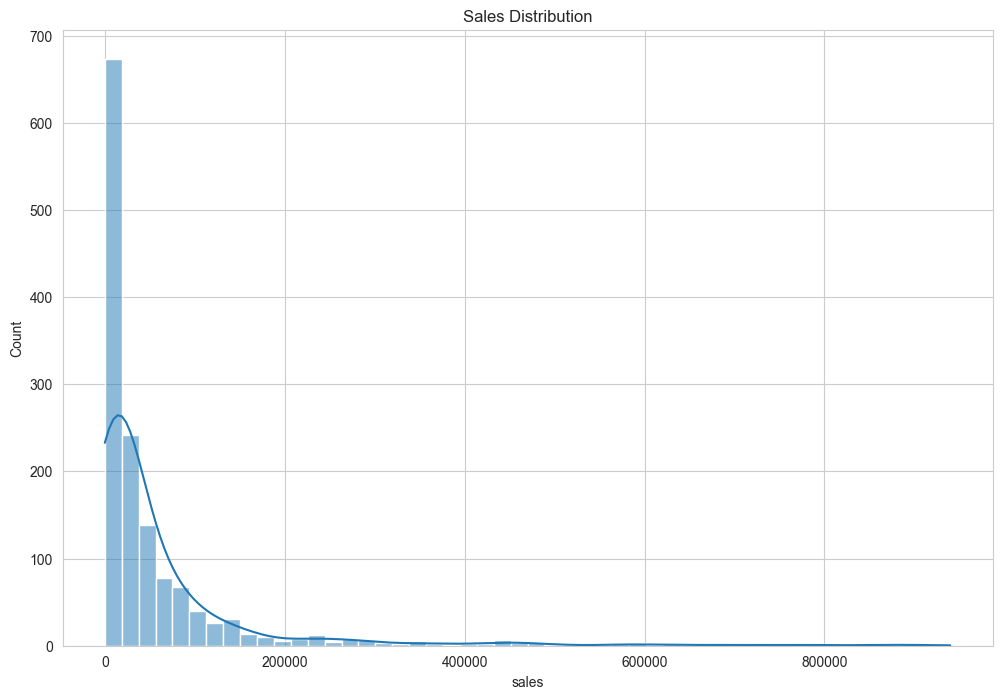

In [35]:
sns.histplot(df['sales'], bins=50, kde=True)
plt.title("Sales Distribution")
plt.show()

2. Net Profit Distribution

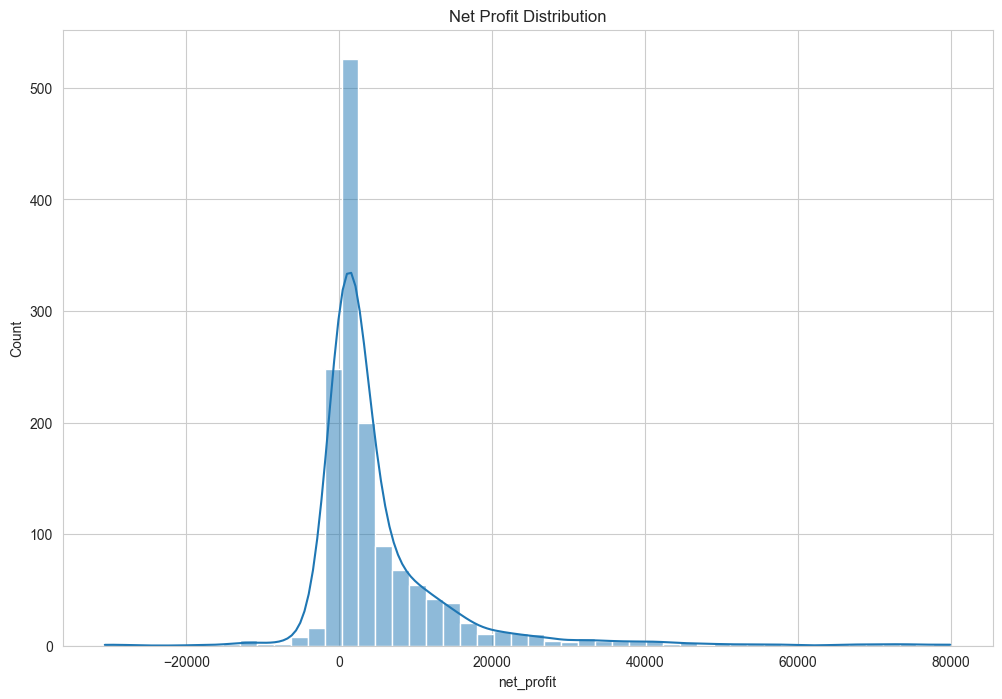

In [36]:
sns.histplot(df['net_profit'], bins=50, kde=True)
plt.title("Net Profit Distribution")
plt.show()

3. Operating Margin Distribution

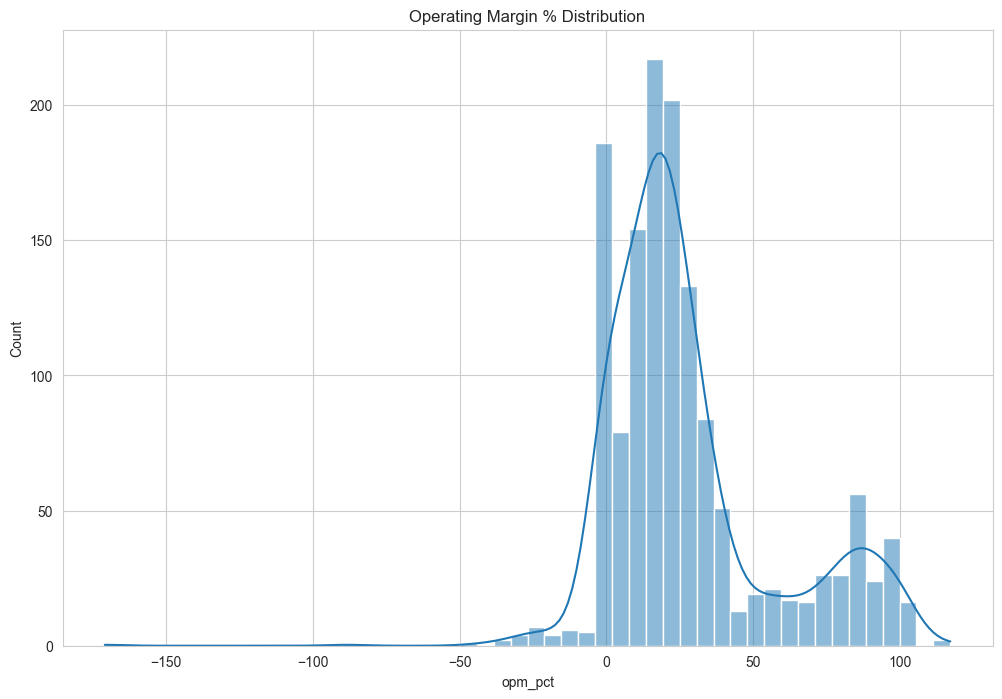

In [37]:
sns.histplot(df['opm_pct'], bins=50, kde=True)
plt.title("Operating Margin % Distribution")
plt.show()

4. Net Profit Margin Distribution

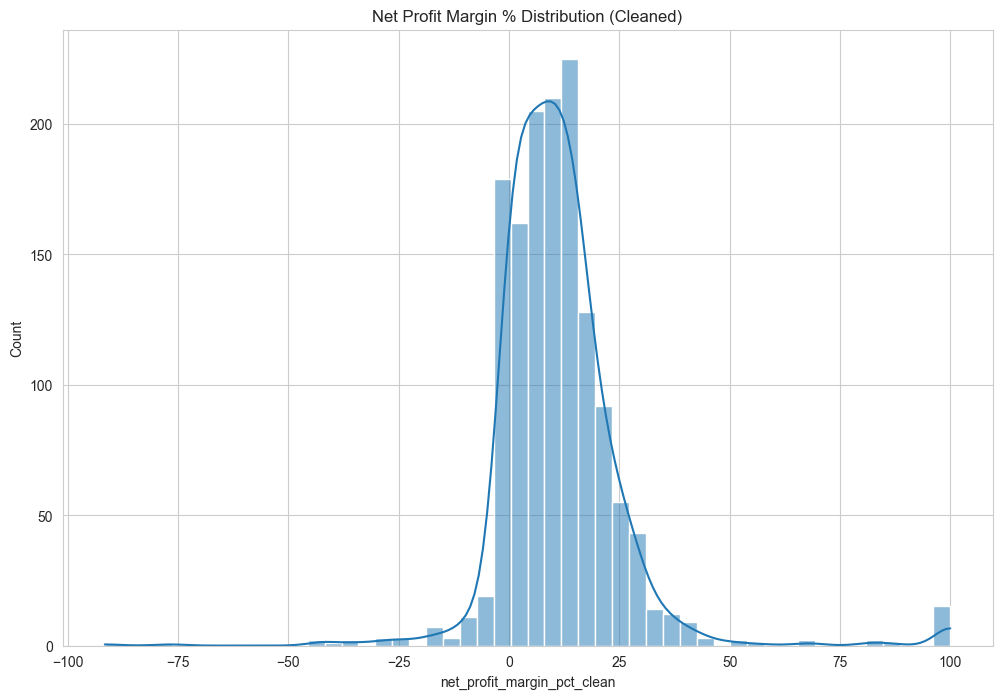

In [38]:
if 'net_profit_margin_pct_clean' not in df.columns:
    df['net_profit_margin_pct_clean'] = pd.to_numeric(
        df['net_profit_margin_pct'], errors='coerce'
    ).clip(lower=-100, upper=100)

sns.histplot(df['net_profit_margin_pct_clean'].dropna(), bins=50, kde=True)
plt.title("Net Profit Margin % Distribution (Cleaned)")
plt.show()

5. Free Cash Flow Distribution

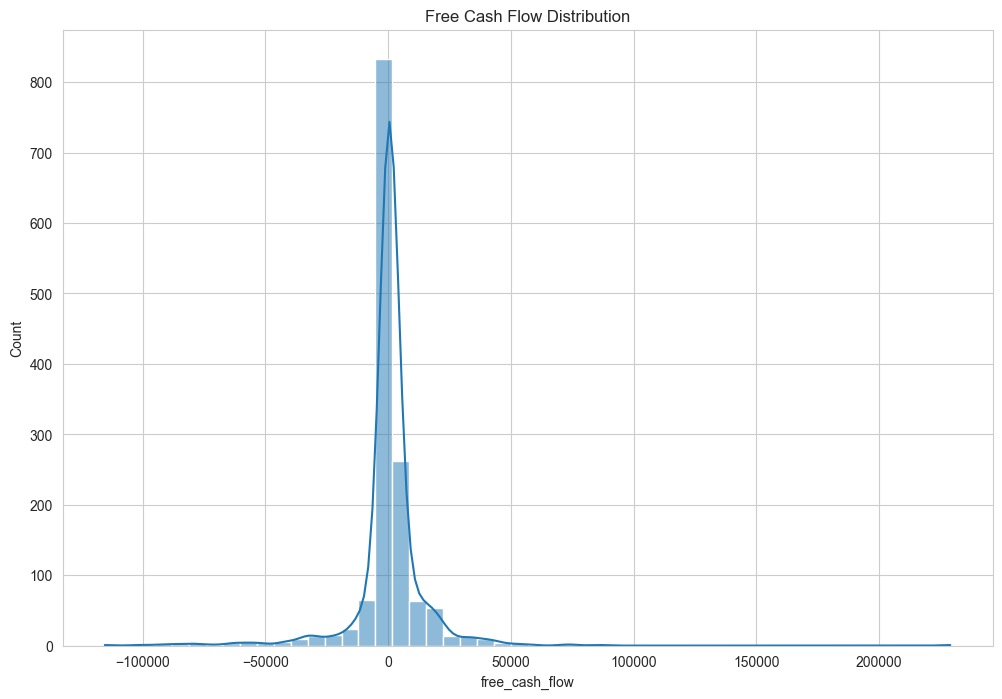

In [39]:
sns.histplot(df['free_cash_flow'], bins=50, kde=True)
plt.title("Free Cash Flow Distribution")
plt.show()

6. Top 10 by Sales

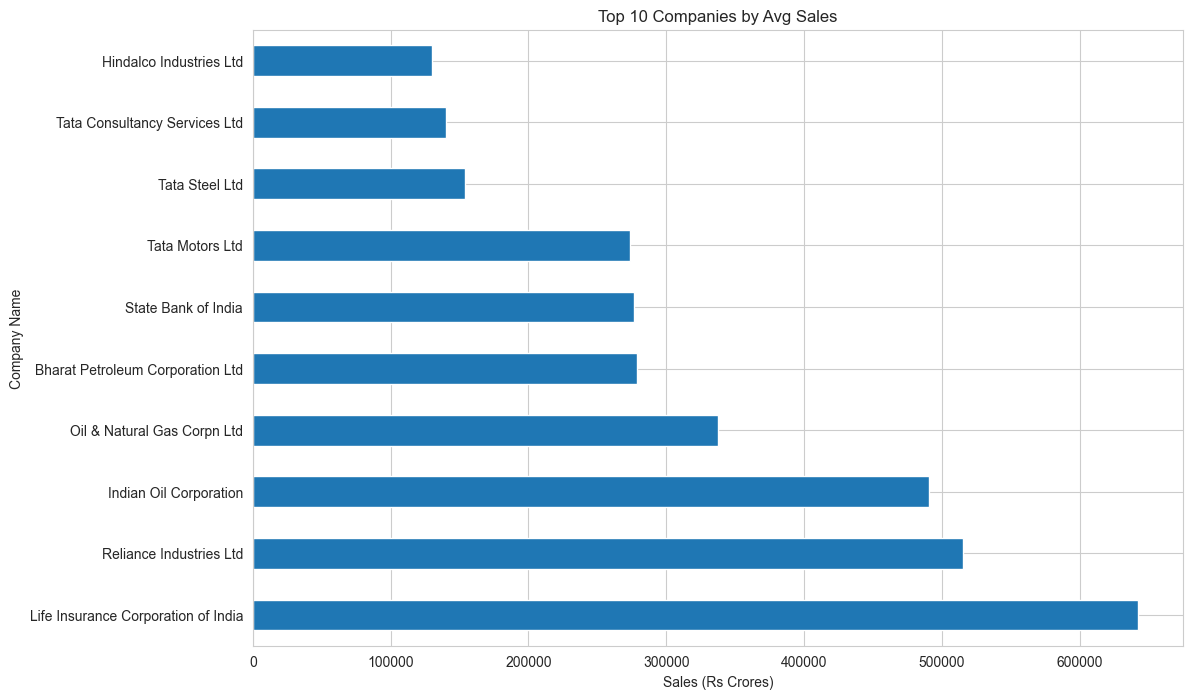

In [40]:
df.groupby('company_name')['sales'].mean().nlargest(10).plot(kind='barh')
plt.title("Top 10 Companies by Avg Sales")
plt.xlabel("Sales (Rs Crores)")
plt.ylabel("Company Name")
plt.show()

7. Bottom 10 by Sales

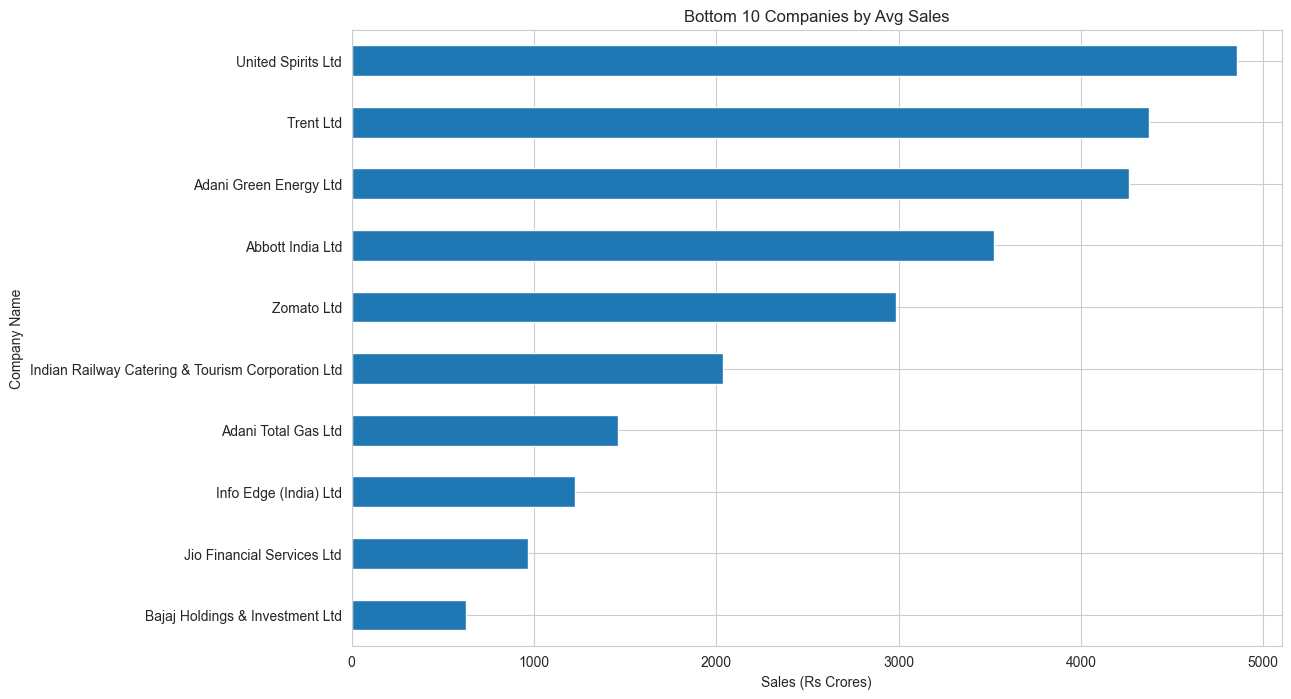

In [41]:
df.groupby('company_name')['sales'].mean().nsmallest(10).plot(kind='barh')
plt.title("Bottom 10 Companies by Avg Sales")
plt.xlabel("Sales (Rs Crores)")
plt.ylabel("Company Name")
plt.show()

8. Top 10 by Net Profit

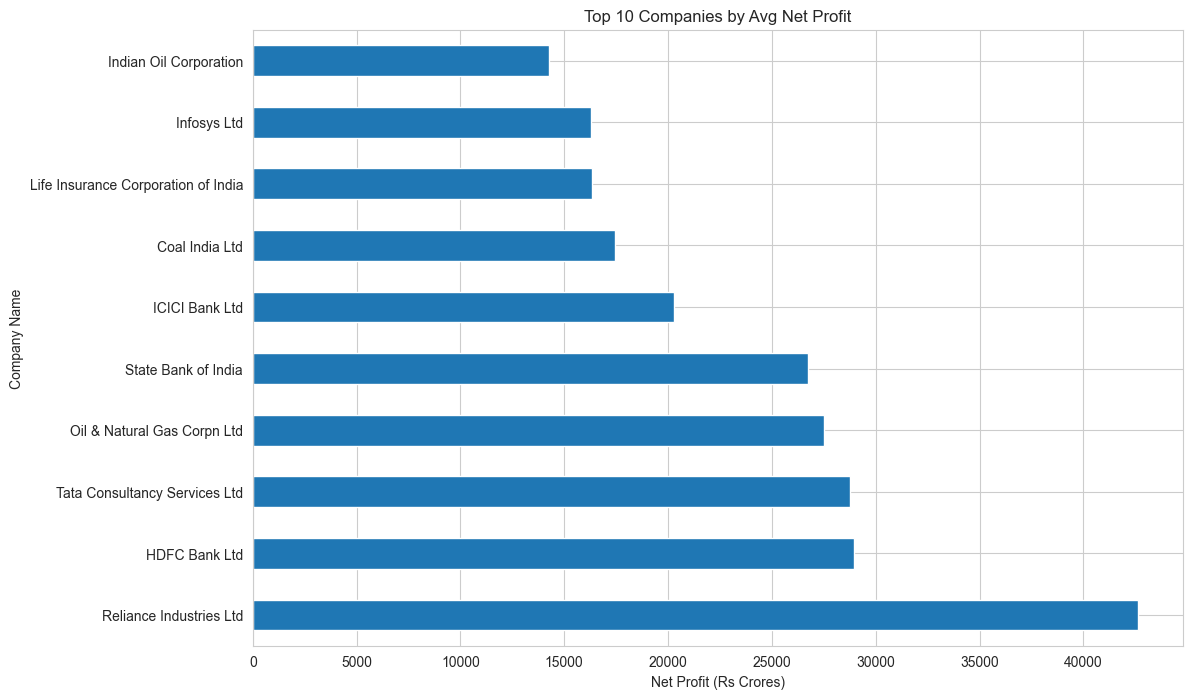

In [42]:
df.groupby('company_name')['net_profit'].mean().nlargest(10).plot(kind='barh')
plt.title("Top 10 Companies by Avg Net Profit")
plt.xlabel("Net Profit (Rs Crores)")
plt.ylabel("Company Name")
plt.show()

9. Bottom 10 by Net Profit

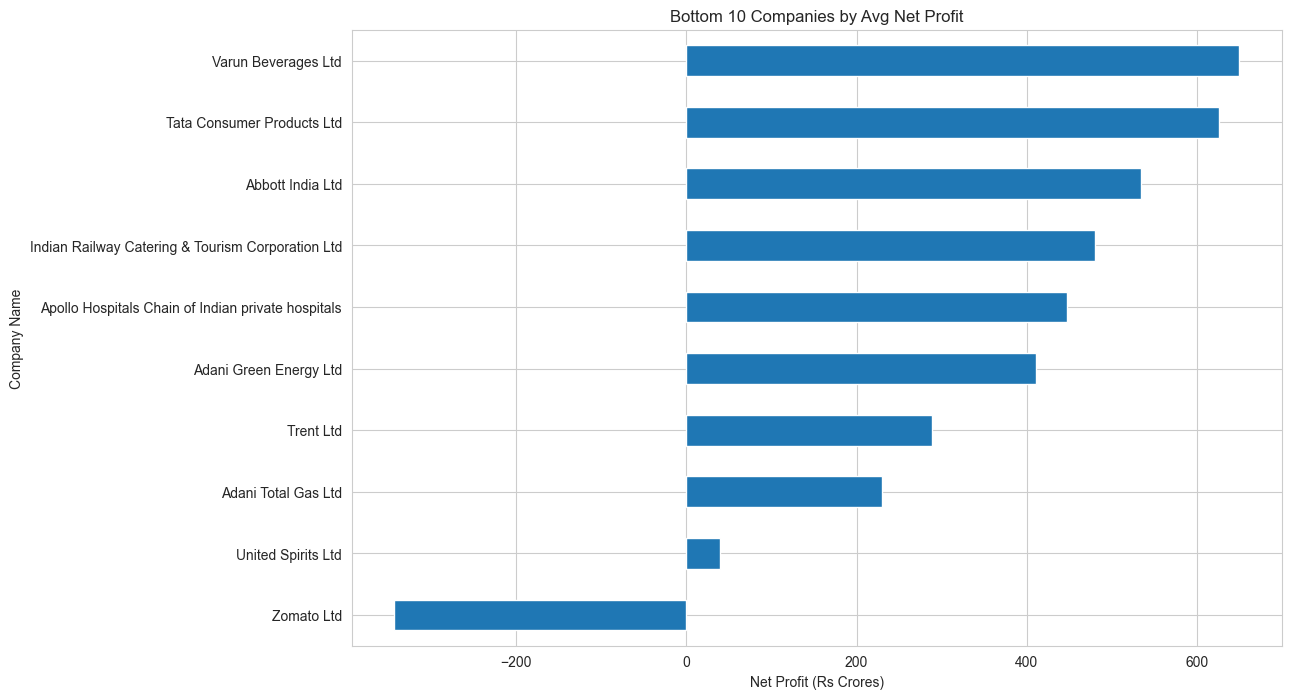

In [43]:
df.groupby('company_name')['net_profit'].mean().nsmallest(10).plot(kind='barh')
plt.title("Bottom 10 Companies by Avg Net Profit")
plt.xlabel("Net Profit (Rs Crores)")
plt.ylabel("Company Name")
plt.show()

10. Top 10 by Free Cash Flow

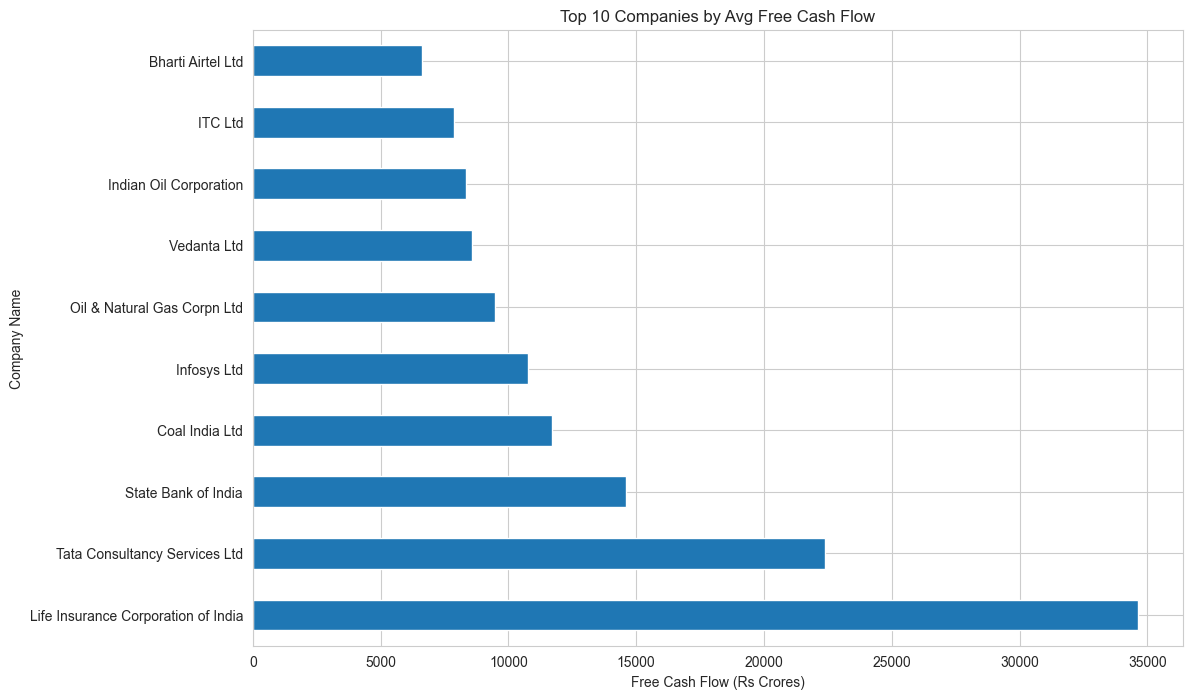

In [44]:
df.groupby('company_name')['free_cash_flow'].mean().nlargest(10).plot(kind='barh')
plt.title("Top 10 Companies by Avg Free Cash Flow")
plt.xlabel("Free Cash Flow (Rs Crores)")
plt.ylabel("Company Name")
plt.show()

11. Correlation Heatmap

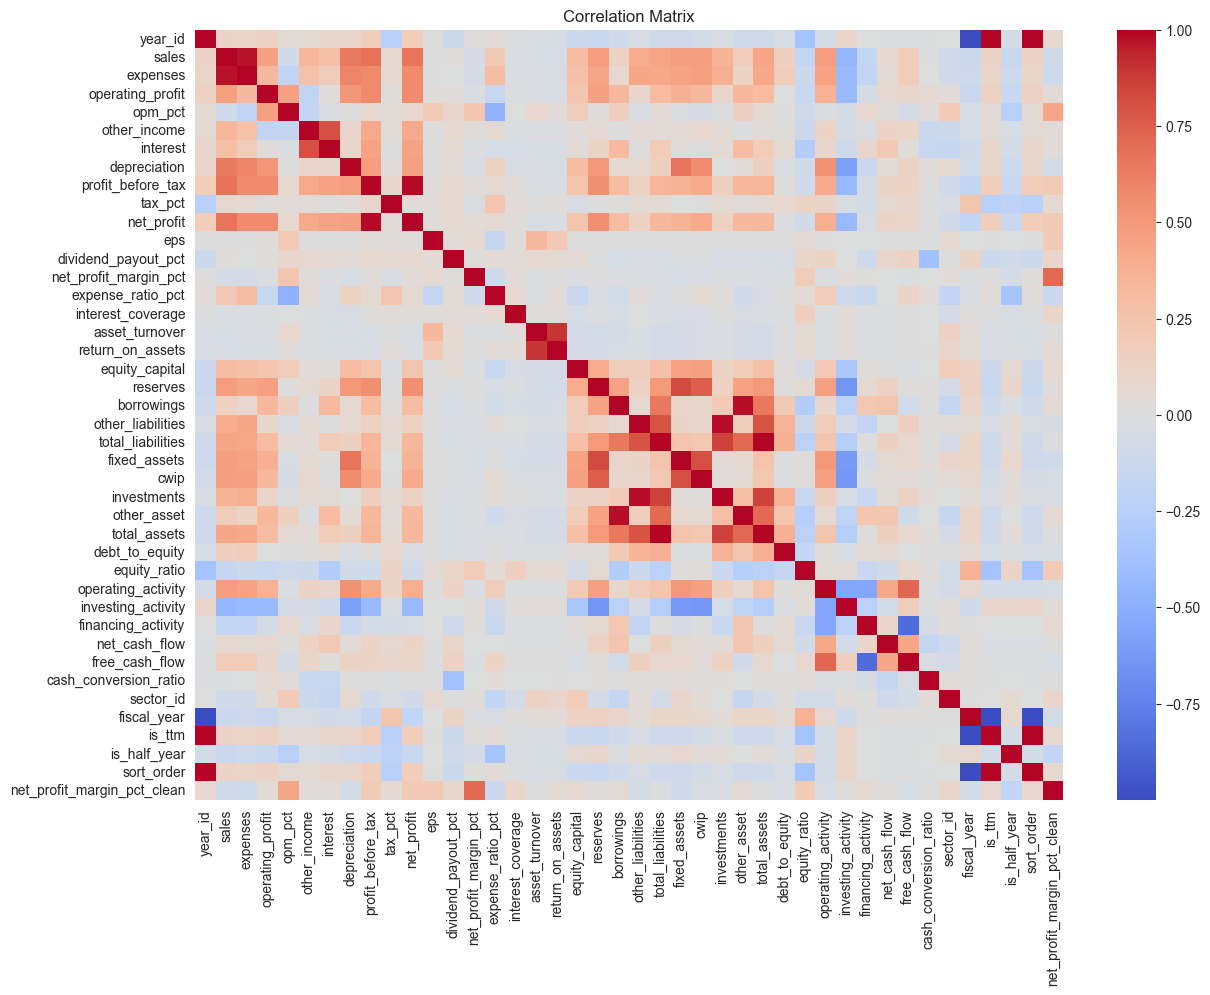

In [45]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(14,10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()

12. OPM vs Net Profit Margin

In [46]:
# Clean OPM and Net Profit Margin for visualization only
df['opm_pct_clean'] = np.where(df['opm_pct'] > 100, df['opm_pct'] / 1000, df['opm_pct'])
df['opm_pct_clean'] = pd.to_numeric(df['opm_pct_clean'], errors='coerce')

df['net_profit_margin_pct_clean'] = pd.to_numeric(df['net_profit_margin_pct'], errors='coerce')
df['net_profit_margin_pct_clean'] = df['net_profit_margin_pct_clean'].clip(lower=-100, upper=100)

print(df[['opm_pct', 'opm_pct_clean', 'net_profit_margin_pct', 'net_profit_margin_pct_clean']].head())

     opm_pct  opm_pct_clean  net_profit_margin_pct  \
0  12.220206      12.220206               8.771930   
1  11.731107      11.731107               8.699473   
2  13.630406      13.630406              10.004369   
3  13.963275      13.963275               9.755164   
4  13.709955      13.709955               9.541853   

   net_profit_margin_pct_clean  
0                     8.771930  
1                     8.699473  
2                    10.004369  
3                     9.755164  
4                     9.541853  


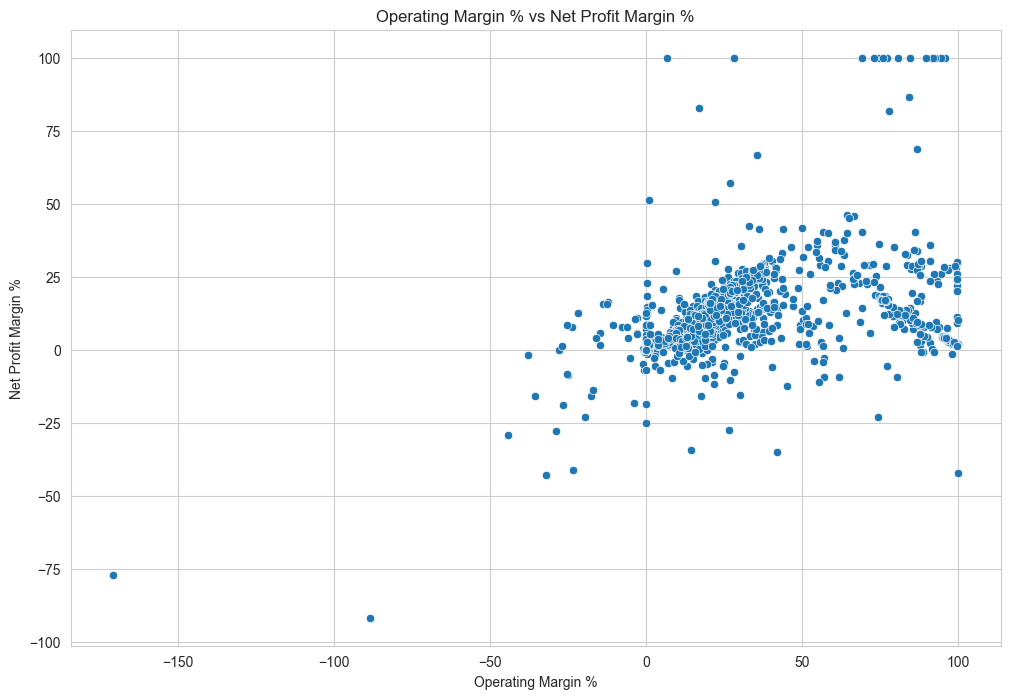

In [47]:
sns.scatterplot(data=df, x='opm_pct_clean', y='net_profit_margin_pct_clean')
plt.title("Operating Margin % vs Net Profit Margin %")
plt.xlabel("Operating Margin %")
plt.ylabel("Net Profit Margin %")
plt.show()

13. Debt vs Profit (Leverage effect)

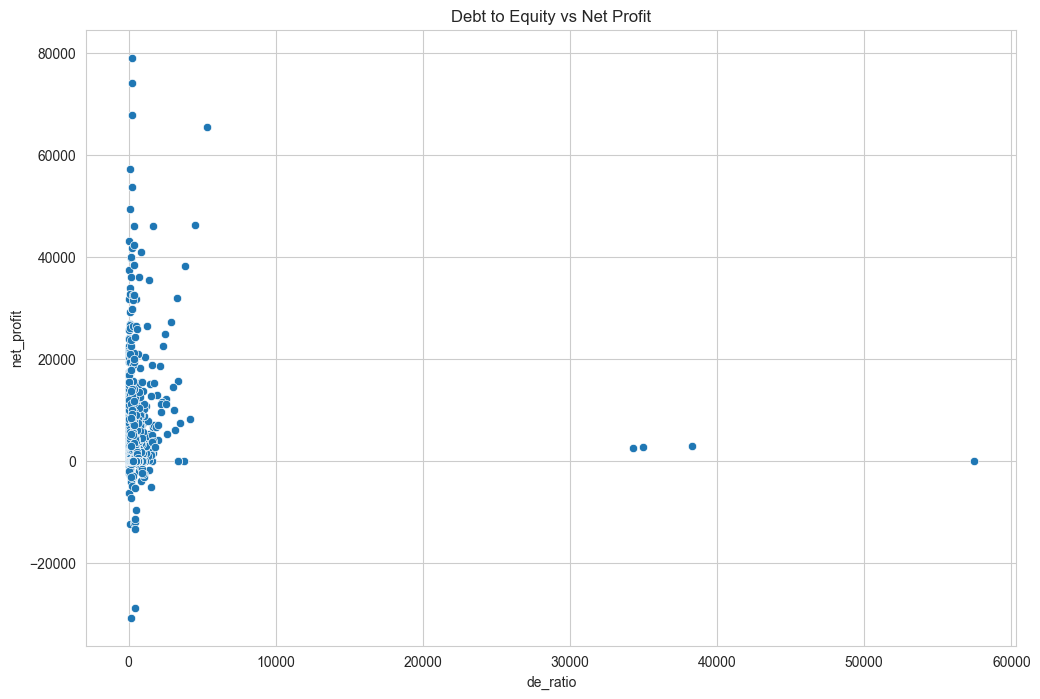

In [48]:
if 'equity_capital' in df.columns and 'total_liabilities' in df.columns:
    df['de_ratio'] = df['total_liabilities'] / df['equity_capital']
    sns.scatterplot(data=df, x='de_ratio', y='net_profit')
    plt.title("Debt to Equity vs Net Profit")
    plt.show()

14. Sector-wise Sales

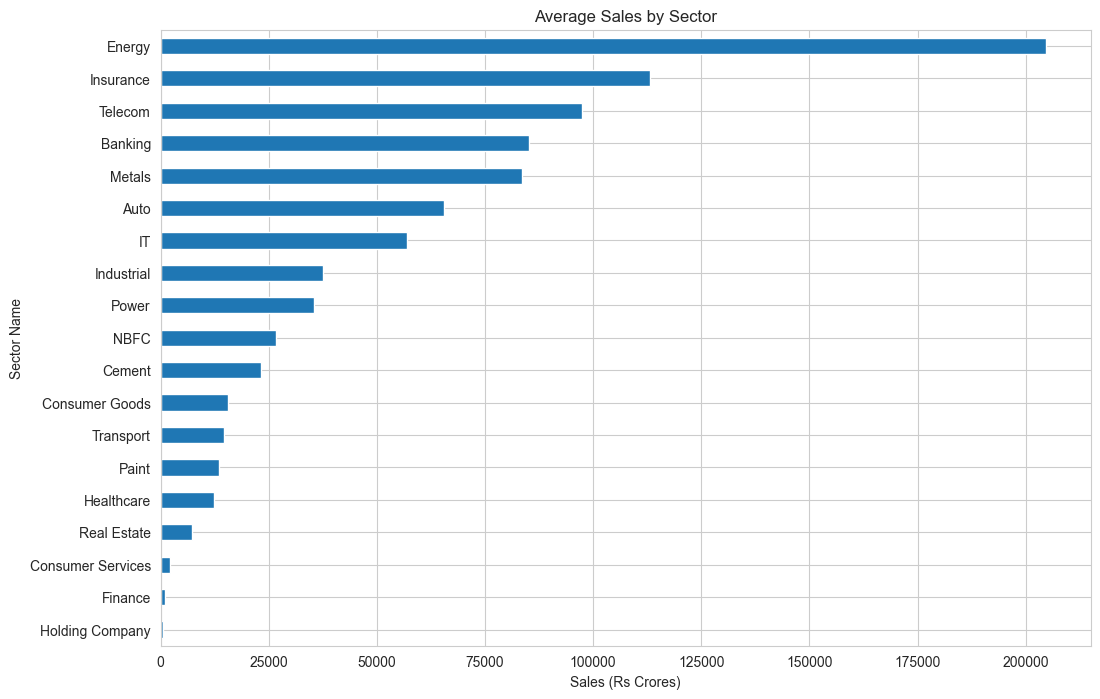

In [49]:
df.groupby('sector_name')['sales'].mean().sort_values().plot(kind='barh')
plt.title("Average Sales by Sector")
plt.xlabel("Sales (Rs Crores)")
plt.ylabel("Sector Name")
plt.show()

15. Sector-wise Profit Margin (Boxplot)

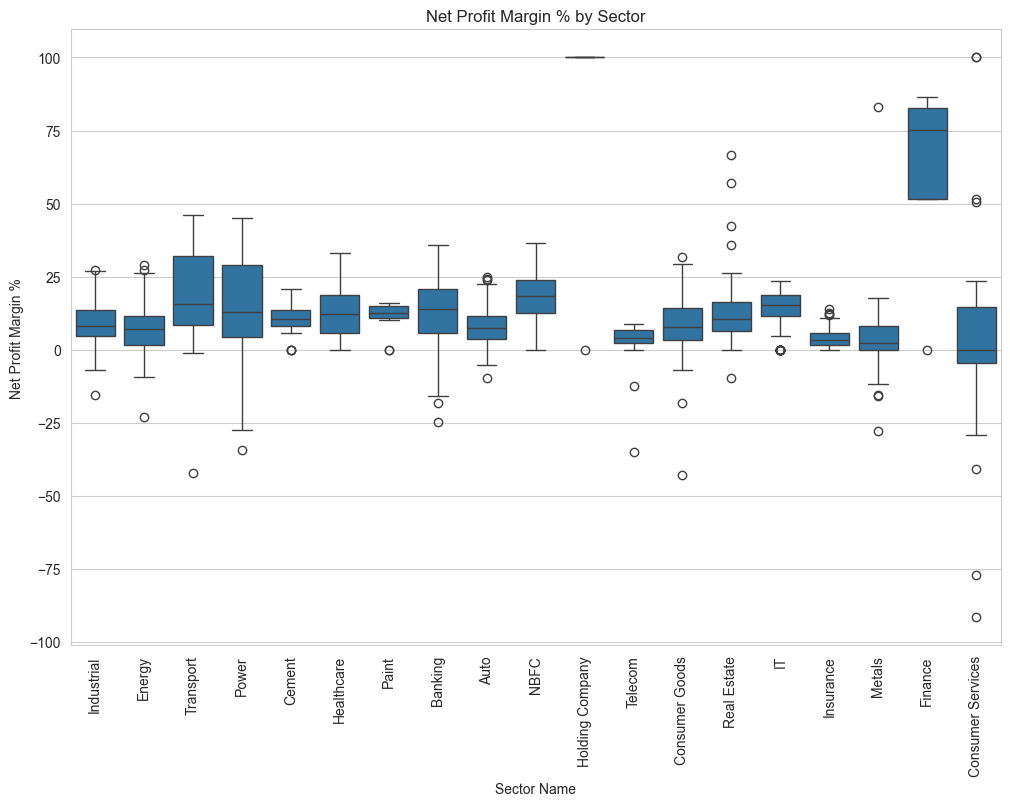

In [50]:
sns.boxplot(data=df, x='sector_name', y='net_profit_margin_pct_clean')
plt.xticks(rotation=90)
plt.title("Net Profit Margin % by Sector")
plt.xlabel("Sector Name")
plt.ylabel("Net Profit Margin %")
plt.show()

16. Sector-wise Free Cash Flow

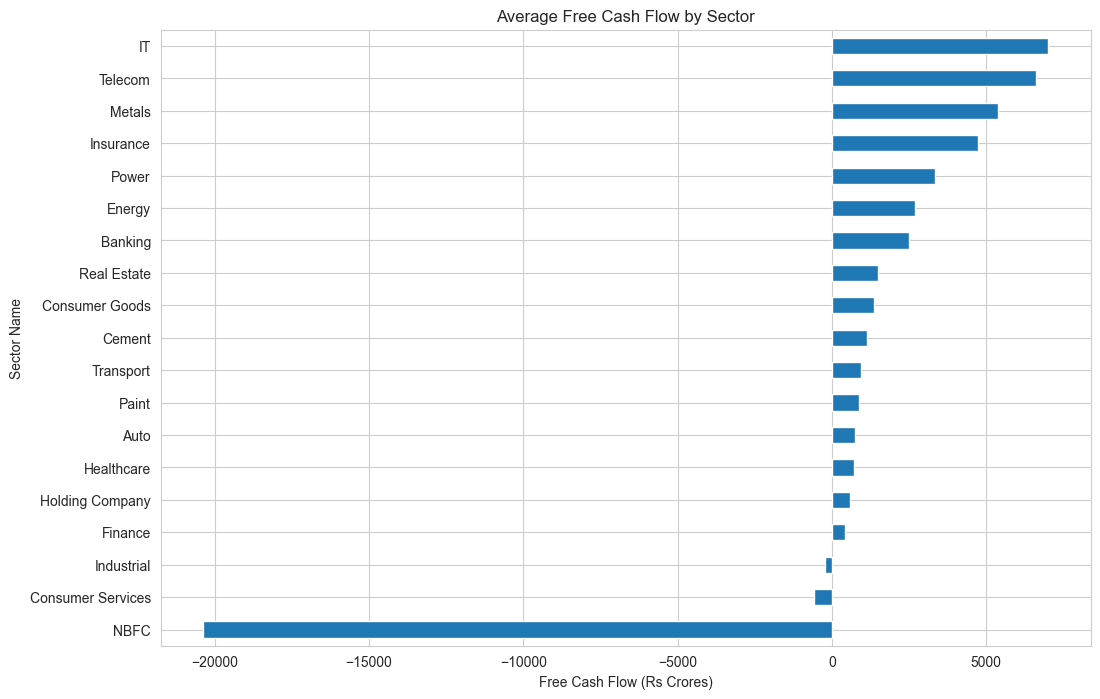

In [51]:
df.groupby('sector_name')['free_cash_flow'].mean().sort_values().plot(kind='barh')
plt.title("Average Free Cash Flow by Sector")
plt.xlabel("Free Cash Flow (Rs Crores)")
plt.ylabel("Sector Name")
plt.show()

17. Missing Value Heatmap

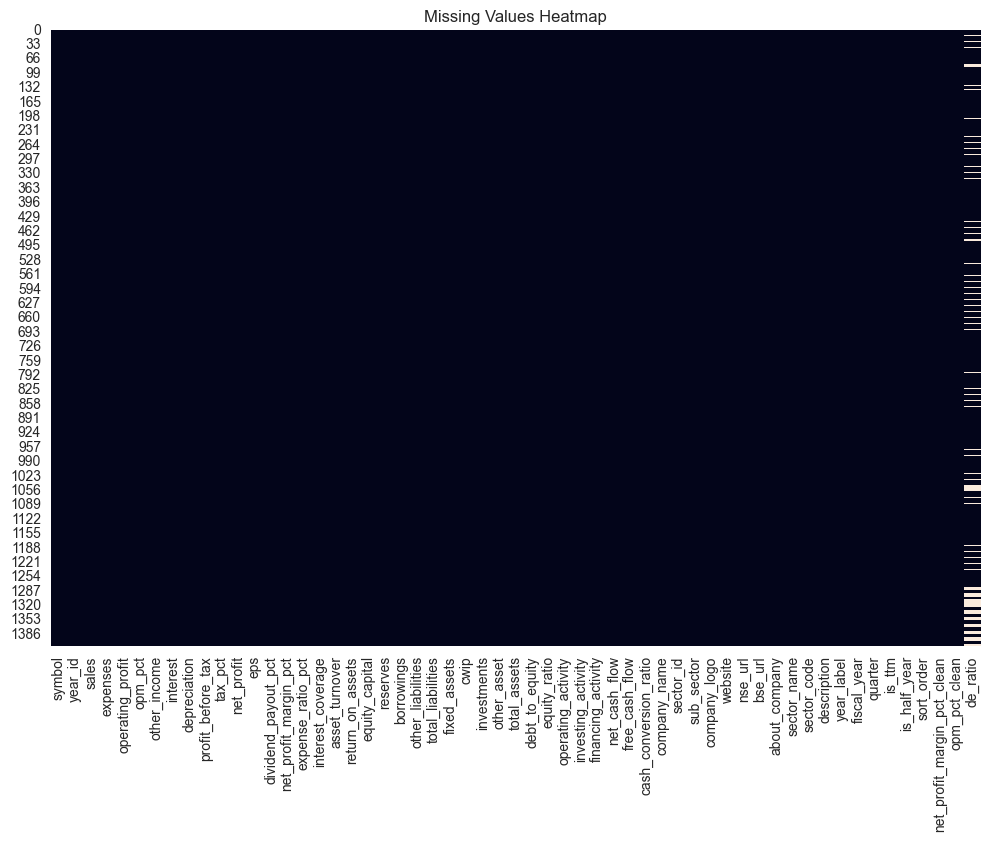

In [52]:
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

18. Missing Count Bar Plot

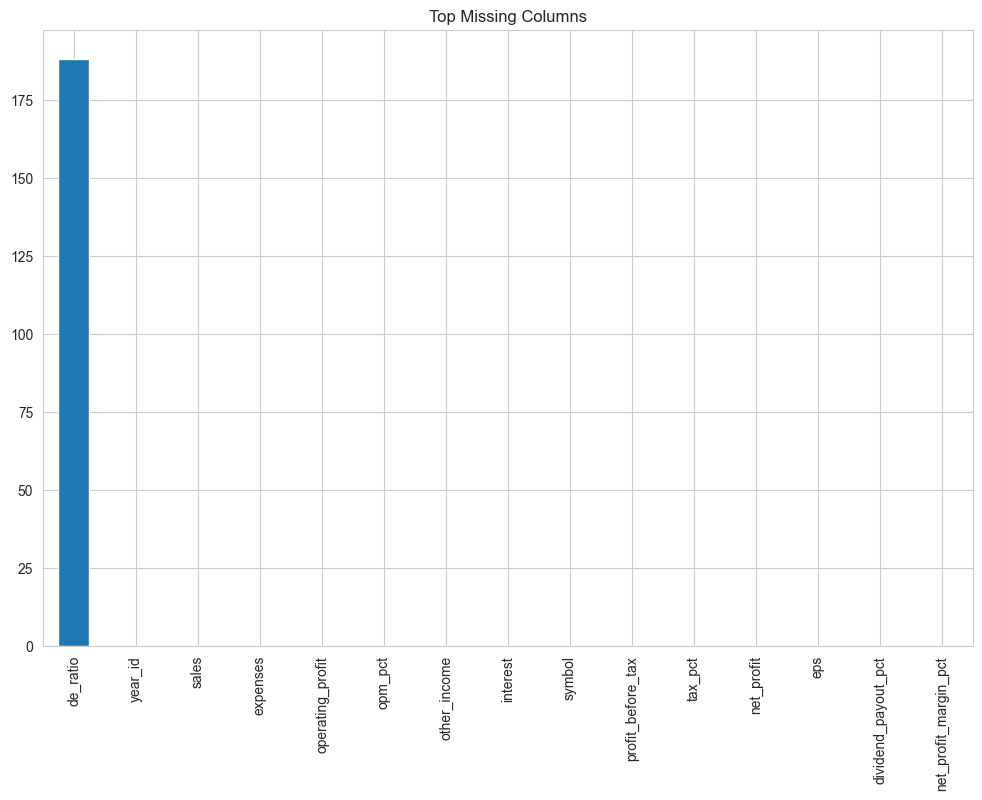

In [53]:
df.isnull().sum().sort_values(ascending=False).head(15).plot(kind='bar')
plt.title("Top Missing Columns")
plt.show()

19. Boxplot for Net Profit

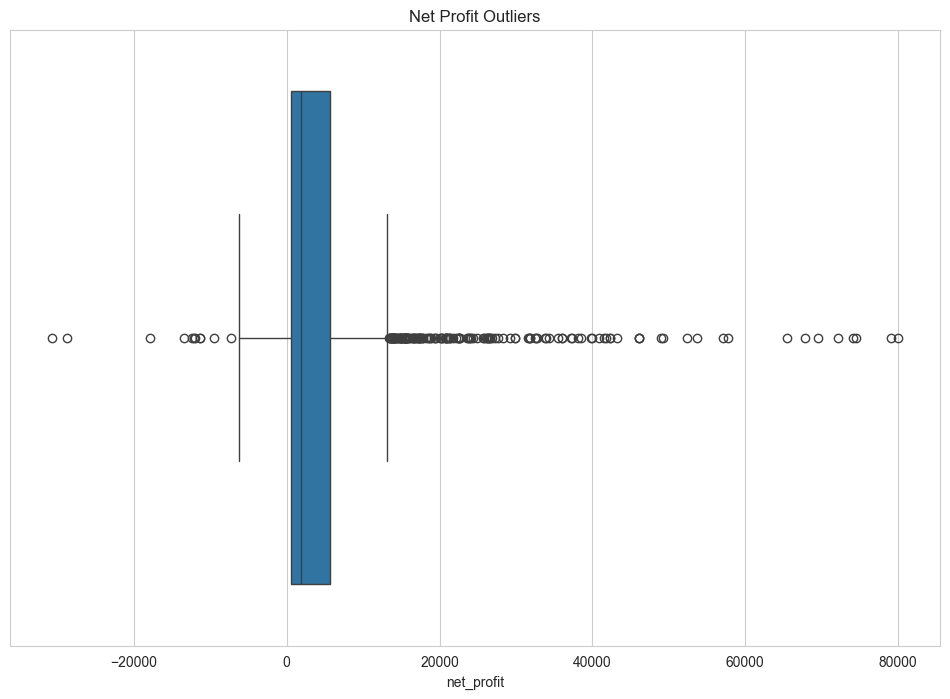

In [54]:
sns.boxplot(x=df['net_profit'])
plt.title("Net Profit Outliers")
plt.show()

20. Z-score Outliers Count

d:\Satvik\Bluestock Fintech\financial-intelligence-platform\venv\Lib\site-packages\scipy\stats\_stats_py.py:1162: RuntimeWarning: invalid value encountered in subtract
  a_zero_mean = a - mean


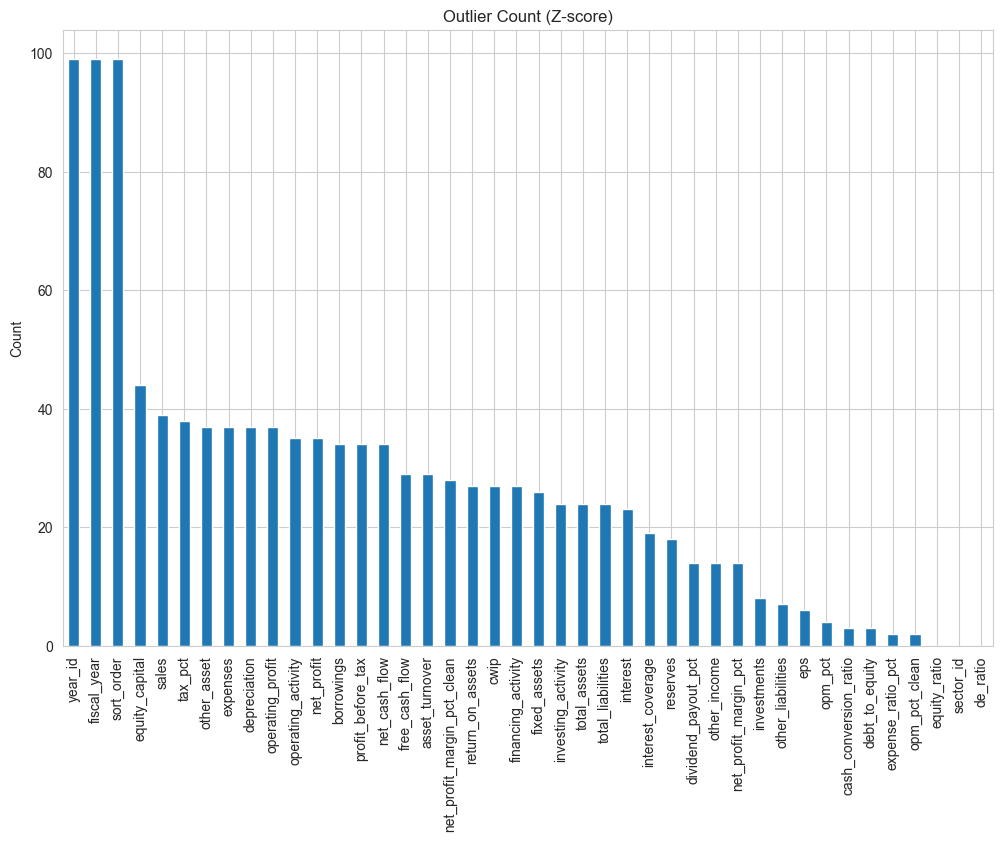

In [55]:
from scipy import stats

numeric_df = df.select_dtypes(include=np.number)
z = np.abs(stats.zscore(numeric_df, nan_policy='omit'))
outliers = pd.Series((z > 3).sum(axis=0), index=numeric_df.columns)

outliers.sort_values(ascending=False).plot(kind='bar')
plt.title("Outlier Count (Z-score)")
plt.ylabel("Count")
plt.show()

SUMMARY

1. Sales and profit are highly right-skewed → large companies dominate.
2. Strong positive correlation between OPM% and net profit margin.
3. Some sectors consistently outperform others in profitability.
4. Presence of extreme outliers in profit and cash flow.
5. Debt-heavy companies tend to show weaker profitability trends.